In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
 
from yieldcurve import YieldCurve
from src.derivative_test import EuropeanCall, EuropeanPut


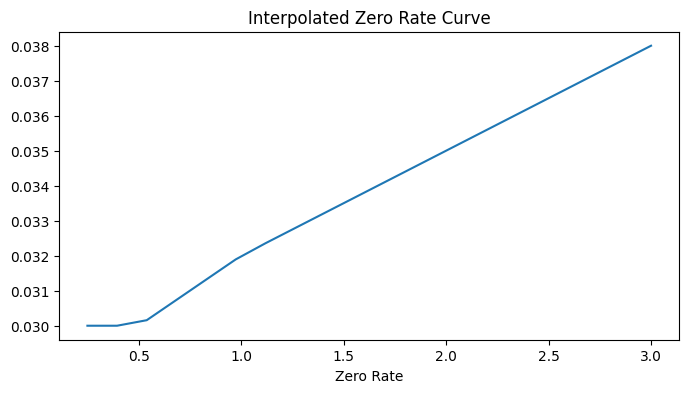

In [14]:
# Construct yield curve.

maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]

yc = YieldCurve (maturities, zero_rates)

# Sanity check on yield curve. 

test_maturities = np.linspace (0.25, 3.0, 20)
rates = [yc.get_zero_rate(T) for T in test_maturities]
dfs = [yc.get_discount_factor(T) for T in test_maturities]

plt.figure (figsize=(8,4))
plt.plot (test_maturities, rates)
plt.title ("Interpolated Zero Rate Curve")
plt.xlabel ("Zero Rate")
plt.show()

In [17]:
S0 = 100
K = 100
T = 1.00
sigma = 0.20

call = EuropeanCall (
    S0 = S0, 
    K = K,
    T = T,
    sigma = sigma, 
    yield_curve = yc
)

put = EuropeanPut (
    S0 = S0, 
    K = K,
    T = T,
    sigma = sigma, 
    yield_curve = yc
)


In [18]:
call_price = float(round(call.price (),4))
put_price = float(round(put.price (),4))

call_price, put_price

print(f"The call price is ${call_price}")
print (f"The put price is ${put_price}")

The call price is $9.5146
The put price is $6.3653


__Sense Checks__
- Volatility should increase both prices. 
- T should increase both price as well (calls more than puts). 
- S0 should increase call price decrease put pirce.
- K should increase put price decrease call price. 

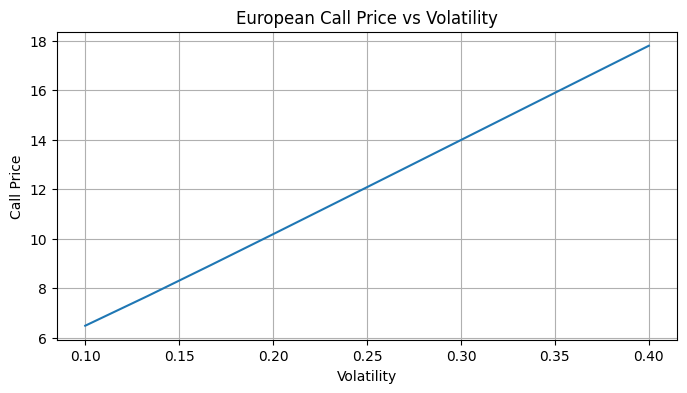

In [11]:
# Volatility Sanity Check
vols = np.linspace (0.1, 0.4, 10)
call_prices = []

for v in vols:
    tmp_call = EuropeanCall (S0, K, T, v, yc)
    call_prices.append (tmp_call.price())

plt.figure (figsize = (8,4))
plt.plot (vols, call_prices)
plt.title ('European Call Price vs Volatility')
plt.xlabel ('Volatility')
plt.ylabel ('Call Price')
plt.grid (True)
plt.show()
